# Batch Processing Example

This notebook demonstrates using the `ScenarioBatch` class to quickly evaluate
multiple variations of environmental or mobility inputs.

1. Constructing **two** synthetic GPS trajectories to compare
2. Building the raster environment
3. Defining **two** mobility models to compare, creating and running the `ScenarioBatch`
4. Visualising the environment and occupancy
5. Visualising exposure time series

All data here is synthetic, constructed directly in the notebook so that
the example is fully self-contained and reproducible without external files.


In [28]:
# Imports
import datetime as dt
import logging

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import box

from geoexposure import (
    Environment, GapMethod, KDE, LandCover, ScenarioBatch, SpatialData,
    Trajectory
)
from geoexposure.data.columns import DATETIME, X, Y

logger = logging.getLogger(__name__)

## 1. Trajectories

A `Trajectory` is a time-ordered sequence of GPS observations `(x, y, datetime)`
Here we construct two trajectories within a 1 km × 1 km grid over approximately
four hours.

Dwell times are assigned using the **Voronoi** gap method, which gives each
point a dwell time equal to half the gap to the previous observation plus half
the gap to the next. This is the simplest strategy and requires no additional
parameters.

In [29]:
# Create sample trajectory data
n = 50
half_n = int(n / 2)
start = dt.datetime(2020, 1, 1, 8, 0, 0)
times = [start + dt.timedelta(minutes=5 * i) for i in range(n)]

# Trajectory 1: direct movement on a 45-degree angle
x_1 = np.linspace(100.0, 900.0, n)
y_1 = np.linspace(100.0, 900.0, n)
df_1 = pd.DataFrame(
    {
        DATETIME: times,
        X       : x_1,
        Y       : y_1
    }
)
trajectory_1 = Trajectory(df_1, source_id="example_1")

# Trajectory 2: two movements at different speeds
first_move = 18
second_move = 32

x_2 = np.concat([
    np.linspace(100.0, 400.0, first_move),
    np.linspace(400.0, 900.0, second_move),
])
y_2 = np.concat([
    np.linspace(100.0, 600.0, first_move),
    np.linspace(600.0, 900.0, second_move),
])
df_2 = pd.DataFrame(
    {
        DATETIME: times,
        X       : x_2,
        Y       : y_2
    }
)
trajectory_2 = Trajectory(df_2, source_id="example_2")

## 2. Environment

An `Environment` combines one or more `SpatialData` layers on a regular raster
grid. Each `SpatialData` layer wraps a vector GeoDataFrame and associates it
with one or more `Metric` objects that are evaluated on the grid.

Here we construct a simple 1 km × 1 km land cover dataset with three categories:

| Category | Geometry                                                    |
|----------|-------------------------------------------------------------|
| `forest` | Left half of the domain (x = 0–500, y=0-1000)               |
| `fields` | Top-right corner of the domain (x = 500–1000, y = 500-1000) |
| `water`  | Bottom-right corner of the domain (x = 500–1000, y = 0-500) |

A `LandCover` metric is attached to each category with equal weighting.
Setting `radius=0.0` means exposure is binary — a cell is either inside or
outside the target land cover, with no distance decay at the boundary.

`environment.calculate()` evaluates all metrics on the raster grid and caches.
the results to disk. This calculation wil be triggered automatically at a
later point in the exposure calculation if not manually called, but
pre-calculating can be helpful for finding bugs early.

In [30]:
# 3 Build the environment

# Underlying spatial data
forest = box(0, 0, 500, 1000)
fields = box(500, 500, 1000, 1000)
water = box(500, 0, 1000, 500)
spatial_data_gdf = gpd.GeoDataFrame(
    {"land_type": ["forest", "fields", "water"]},
    geometry=[forest, fields, water],
    crs="EPSG:32648",
)

# Metrics related to specific land types
forest_metric = LandCover(radius=0.0, column="land_type", value="forest")
fields_metric = LandCover(radius=0.0, column="land_type", value="fields")
water_metric = LandCover(radius=0.0, column="land_type", value="water")
weighting = 1.0

# Construct environment and calculate metrics
spatial_data = {
    "land": SpatialData(
        spatial_data_gdf,
        metrics={
            forest_metric: weighting,
            fields_metric: weighting,
            water_metric : weighting,
        },
    )
}
environment = Environment(
    spatial_resolution=10,
    spatial_data=spatial_data,
    spatial_reference_data="land",
)
environment.calculate()

## 3. Mobility Model and Scenario

A **mobility model** estimates how a participant distributes their time across
the raster grid given their trajectory.

In thie example we construct two **Kernel Density Estimation** (KDE) models with
bandwidths of 50 and 100 metres. This approach places a Gaussian kernel at each
recorded position weighted by its dwell time (computed with the voronoi method
as described), then evaluates the resulting density on the environment grid.

A `ScenarioBatch` accept single instances or lists of every type uses by `Scenario`.
The batch can then be processed with a single call in either "product" mode which
computes all permutations of the inputs, or "zip" mode which uses the values in
order along any list inputs. One of these modes must be provided as an argument to
 `batch.process`. Any single value arguments are used in all scenarios.

To avoid memory overheads when working with large batches, this method does not
store and return results directly but saves them to a specified output directory.
Results can be accessed with `batch.load_results` which uses the unique paths
generated from the keys to load the matching data.

In [31]:
# 4 Define the mobility model and run the scenario
kde_50 = KDE(kernel="gaussian", bandwidth=50.0)
kde_100 = KDE(kernel="gaussian", bandwidth=100.0)

# Construct and calculate all scenarios
batch = ScenarioBatch(
    trajectories=(
        trajectory_1,
        trajectory_2,
    ),
    environments=environment,
    mobility_models={
        "kde_50" : kde_50,
        "kde_100": kde_100,
    },
    gap_methods=(GapMethod.VORONOI, None),
    timesteps=dt.timedelta(minutes=5),
)
output_dir = "batch_output_example"
keys = batch.process(mode="product", output_dir=output_dir)
results = batch.load_results(keys, output_dir)

## 4. Visualisation Spatial Data

This figure shoes the land cover environment with the:
- trajectory 1 overlaid as red points. The diagonal path crosses both the forest (top)
  and fields (bottom) regions.
- trajectory 2 overlaid as cyan crosses. This path sits further from the water region
  in the lower-right and moves in two sections - first quickly then slowly.

Text(0.5, 1.0, 'Environment with trajectories')

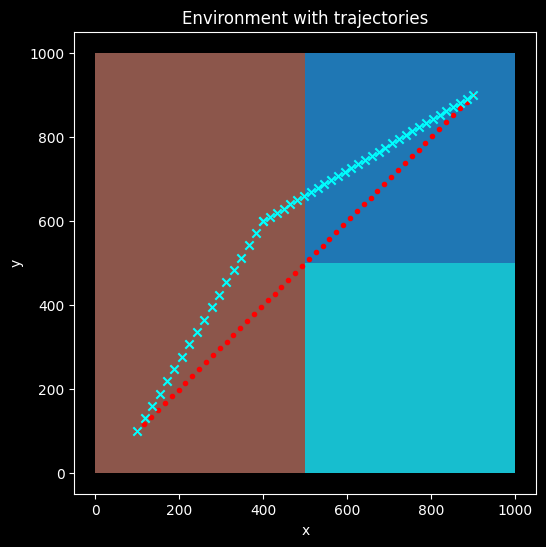

In [32]:
# # 5 Visualise

# Environmental layer with trajectory points
fig, ax = plt.subplots(1, 1, sharex=True, sharey=True)
fig.set_size_inches(6, 6)
ax = environment.plot_reference(ax=ax, column="land_type")
ax.scatter(trajectory_1.df["x"], trajectory_1.df["y"], color="red", marker='.')
ax.scatter(trajectory_2.df["x"], trajectory_2.df["y"], color="cyan", marker='x')
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Environment with trajectories")

This figure shows the computed occupancy distribution for each combination of
trajectory and mobility model. Increasing the KDE bandwidth increases the
spatial spread of the occupancy. The difference in travel speed between the
first and second half of trajectory 2 creates distinct regions with different
densities.

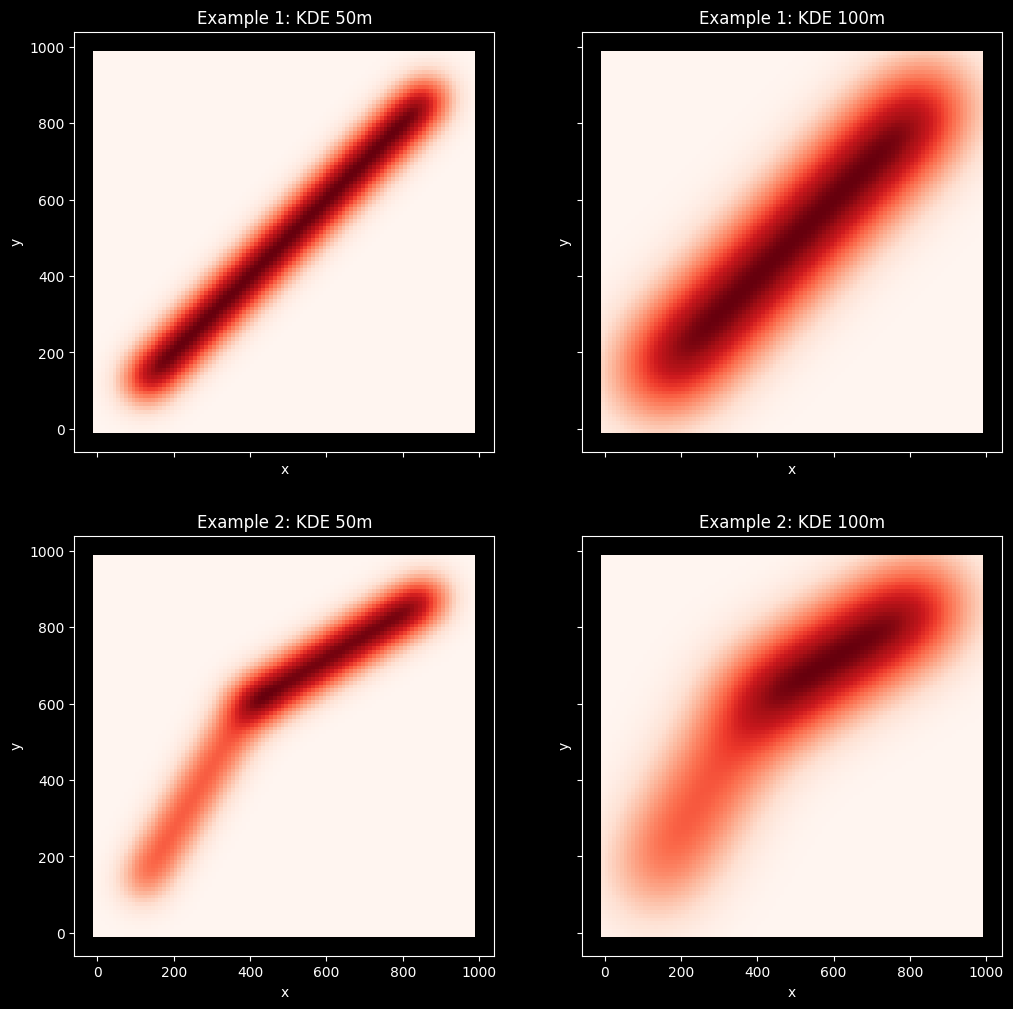

In [33]:
# Occupancy on raster grid derived with mobility model
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
fig.set_size_inches(12, 12)
titles = (
    "Example 1: KDE 50m",
    "Example 1: KDE 100m",
    "Example 2: KDE 50m",
    "Example 2: KDE 100m",
)
for ax, result, title in zip(axes.flat, results, titles, strict=True):
    occupancy = result.occupancy_gdf()
    ax = occupancy.plot(ax=ax, column="density", cmap=plt.cm.Reds)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title(title)

## 5. Exposure Time Series

This figure shows the exposure of time for the four scenarios in the processed
batch.

Each panel shows how much time (in seconds) the participant spent in
each land cover type within each 5-minute window. The lines correspond to
the land cover metrics defined in the environment. The smooth crossover at the
centre arises from the bandwidth of the KDE mobility model.

Note that the values sum to approximately the window length (300 seconds) in
windows where the trajectory is fully within the domain, reflecting the
time-weighted nature of the exposure calculation.

Clear differences between the two trajectories can be observed. We can also
see that a higher bandwidth results in more exposure to the water region.

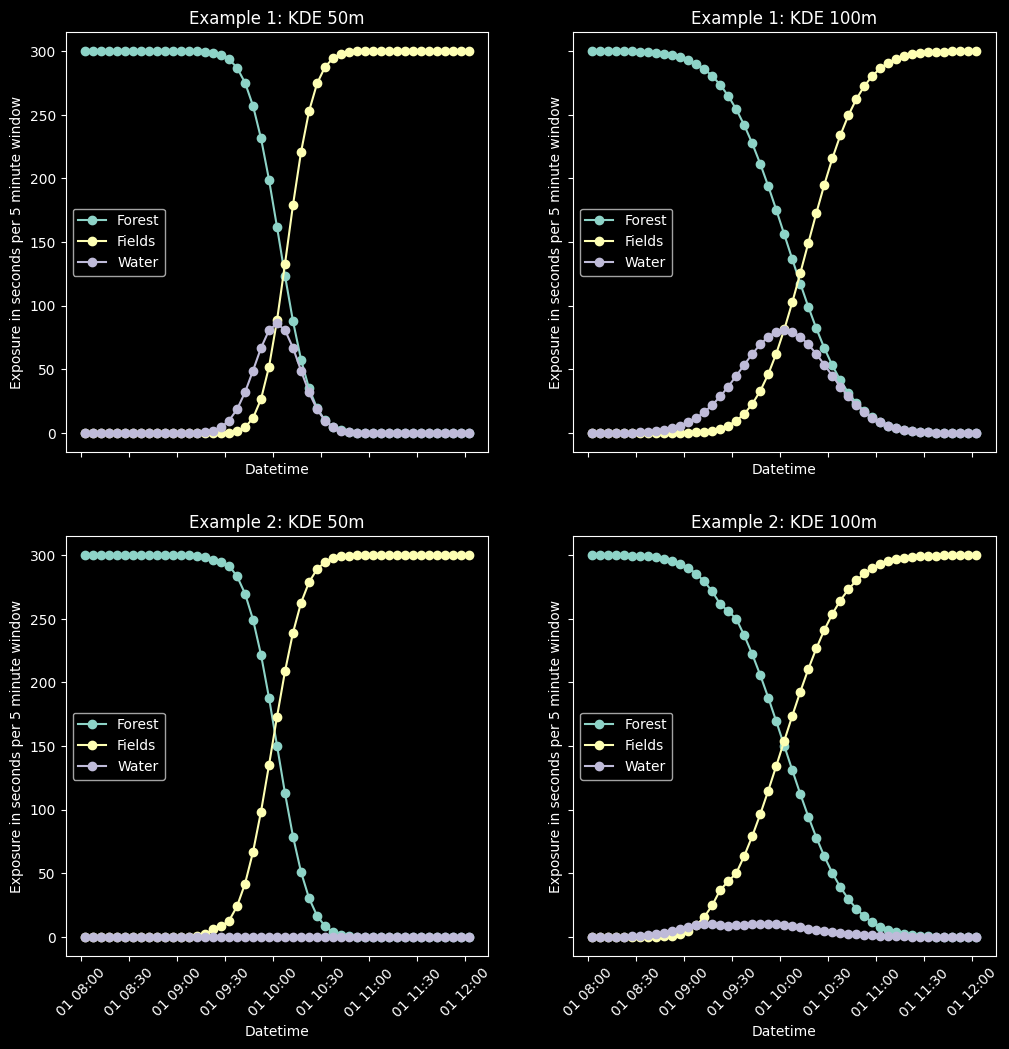

In [34]:
# Occupancy on raster grid derived with mobility model
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
fig.set_size_inches(12, 12)
titles = (
    "Example 1: KDE 50m",
    "Example 1: KDE 100m",
    "Example 2: KDE 50m",
    "Example 2: KDE 100m",
)
legend_entries = (
    "Forest",
    "Fields",
    "Water",
)
for ax, result, title in zip(axes.flat, results, titles, strict=True):
    df = result.exposure.dataframe
    ax.plot(df["window_centre"], df[environment.columns], marker='o')
    ax.legend(legend_entries, loc="center left")
    ax.set_xlabel("Datetime")
    ax.set_ylabel("Exposure in seconds per 5 minute window")
    ax.tick_params("x", rotation=45)
    ax.set_title(title)